# Convolutional Neural Networks

# Importar Librerías

In [1]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
import keras
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import (
 #   BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
#)
from keras.layers import LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam



# Cargar set de Imágenes

In [ ]:
import os
import cv2
import numpy as np
import re

# Tu ruta principal
dirname = 'C:/Users/adria/Desktop/Carpetas/Escuela/IA/Proyecto 2/DN3'
imgpath = dirname + os.sep 

images = []
labels = [] # <-- Lista para guardar las etiquetas numéricas
directories = []    
dircount = []
prevRoot = ''
cant = 0
indice_carpeta = -1 # Comienza en -1 para que la primera carpeta sea la clase 0

print("Leyendo imagenes de: ", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    
    # Lógica para detectar cuando cambiamos de carpeta (de un animal a otro)
    if prevRoot != root and root != imgpath:
        prevRoot = root
        directories.append(root)
        indice_carpeta += 1 # Aumentamos el número de clase (0, 1, 2...)
        if cant > 0:
            dircount.append(cant)
            cant = 0
            
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename, re.IGNORECASE): 
            filepath = os.path.join(root, filename)
            
            try:
                # 1. Leemos con OpenCV (asegura 3 canales descartando la transparencia)
                img = cv2.imread(filepath)
                
                # Si la imagen no está corrupta
                if img is not None:
                    # 2. Convertimos colores de BGR a RGB
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    # 3. Forzamos a 128x128 estrictamente
                    img_resized = cv2.resize(img, (128, 128))
                    
                    # 4. Guardamos la imagen y su etiqueta correspondiente
                    images.append(img_resized)
                    labels.append(indice_carpeta)
                    cant += 1
                    
            except Exception as e:
                pass # Si algo falla con una foto, la ignora y sigue con la siguiente

# Agregamos el conteo de la última carpeta
if cant > 0:
    dircount.append(cant)

# --- RESULTADOS DE LA LECTURA ---
print('Directorios leidos:', len(directories))
print("Imagenes en cada directorio:", dircount)
print('Suma Total de imagenes válidas cargadas:', len(images))

# --- CONVERSIÓN A NUMPY (EL MOMENTO DE LA VERDAD) ---
print("\nConvirtiendo listas a arreglos de NumPy...")

# Convertimos las etiquetas a arreglo
y = np.array(labels)

# Convertimos las imágenes a arreglo (ahora sí, todas son idénticas)
X = np.array(images, dtype=np.uint8)

print("✅ ¡Éxito! Forma de X (imágenes):", X.shape)
print("✅ Forma de y (etiquetas):", y.shape)

Leyendo imagenes de:  C:/Users/adria/Desktop/Carpetas/Escuela/IA/Proyecto 2/DN3\
Directorios leidos: 5
Imagenes en cada directorio: [5024, 5002, 5008, 5005, 5006]
Suma Total de imagenes válidas cargadas: 25045

Convirtiendo listas a arreglos de NumPy...
✅ ¡Éxito! Forma de X (imágenes): (25045, 128, 128, 3)
✅ Forma de y (etiquetas): (25045,)


# Creamos las etiquetas

In [23]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  25045


In [24]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 bird
1 frog
2 monkey
3 spider
4 whale


In [25]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [26]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (20036, 128, 128, 3) (20036,)
Testing data shape :  (5009, 128, 128, 3) (5009,)


Text(0.5, 1.0, 'Ground Truth : 3')

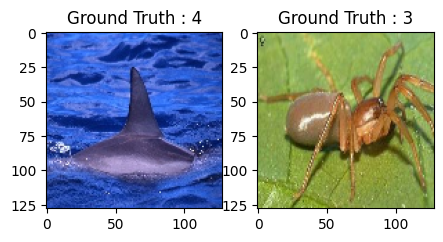

In [27]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

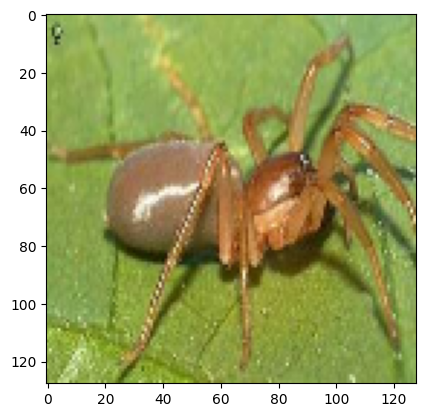

In [28]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [29]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 4
After conversion to one-hot: [0. 0. 0. 0. 1.]


# Creamos el Set de Entrenamiento y Validación

In [30]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=48)

In [31]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(16028, 128, 128, 3) (4008, 128, 128, 3) (16028, 5) (4008, 5)


# Creamos el modelo de CNN

In [32]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 50 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 32 # cantidad de imágenes que se toman a la vez en memoria

In [33]:
sport_model = Sequential()

sport_model.add(Conv2D(32, kernel_size=(3, 3),
activation='linear',
padding='same',
input_shape=(128,128,3)))

sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))
sport_model.add(Dropout(0.5))

sport_model.add(Flatten())

sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))

sport_model.add(Dense(nClasses, activation='softmax'))

In [34]:
sport_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │     4,194,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,195,397 (16.00 MB)

 Trainable params: 4,195,397 (16.00 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
sport_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [36]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

Epoch 1/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.3725 - loss: 1.4156 - val_accuracy: 0.5294 - val_loss: 1.1897
Epoch 2/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.4626 - loss: 1.2430 - val_accuracy: 0.5424 - val_loss: 1.1210
Epoch 3/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.5075 - loss: 1.1685 - val_accuracy: 0.5918 - val_loss: 1.0437
Epoch 4/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.5334 - loss: 1.1247 - val_accuracy: 0.6075 - val_loss: 1.0006
Epoch 5/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.5558 - loss: 1.0838 - val_accuracy: 0.6397 - val_loss: 0.9661
Epoch 6/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.5799 - loss: 1.0463 - val_accuracy: 0.6495 - val_loss: 0.9394
Epoch 7/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.5996 - loss: 1.0141 - val_accuracy: 0.6751 - val_loss: 0.9002
Epoch 8/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.6141 - loss: 0.9900 - 

In [37]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
#transfer_model.save("/content/DN2/40EpocasBalanceado128.keras")
sport_model.save("C:/Users/adria/Desktop/Carpetas/Escuela/IA/Proyecto 2/50epocas128CNN.keras")

# Evaluamos la red

In [38]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7954 - loss: 0.5434


In [39]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.5433506965637207
Test accuracy: 0.7953683137893677


In [40]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Usamos tu variable valid_X para predecir
y_pred = sport_model.predict(valid_X)

# 2. Comparamos contra tus respuestas reales (valid_label)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(valid_label, axis=1)

# 3. Imprimimos la boleta real
print(classification_report(y_true_classes, y_pred_classes, target_names=['bird', 'frog', 'monkey', 'spider', 'whale']))

126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
              precision    recall  f1-score   support

        bird       0.73      0.64      0.68       797
        frog       0.82      0.84      0.83       822
      monkey       0.74      0.75      0.75       791
      spider       0.72      0.81      0.76       784
       whale       0.95      0.94      0.94       814

    accuracy                           0.79      4008
   macro avg       0.79      0.79      0.79      4008
weighted avg       0.80      0.79      0.79      4008



In [41]:
sport_train.history

{'accuracy': [0.3725355565547943,
  0.4626278877258301,
  0.507486879825592,
  0.5334414839744568,
  0.5558397769927979,
  0.579860270023346,
  0.5995757579803467,
  0.6140503883361816,
  0.628213107585907,
  0.6378213167190552,
  0.6479285955429077,
  0.6610307097434998,
  0.666084349155426,
  0.672947347164154,
  0.6810581684112549,
  0.6910406947135925,
  0.6952832341194153,
  0.6966558694839478,
  0.7047042846679688,
  0.7112553119659424,
  0.7126278877258301,
  0.7186797857284546,
  0.7249189019203186,
  0.7297229766845703,
  0.7322810292243958,
  0.7296605706214905,
  0.7377713918685913,
  0.7463813424110413,
  0.7456950545310974,
  0.7478787302970886,
  0.7531819343566895,
  0.758672297000885,
  0.757424533367157,
  0.7625405788421631,
  0.7645370364189148,
  0.7662839889526367,
  0.7704017758369446,
  0.7746443748474121,
  0.7732717990875244,
  0.7767032980918884,
  0.7788869738578796,
  0.7806962728500366,
  0.7847517132759094,
  0.7900549173355103,
  0.790865957736969,
  0.79

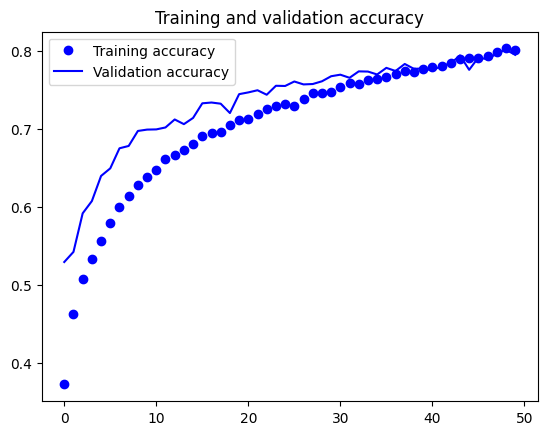

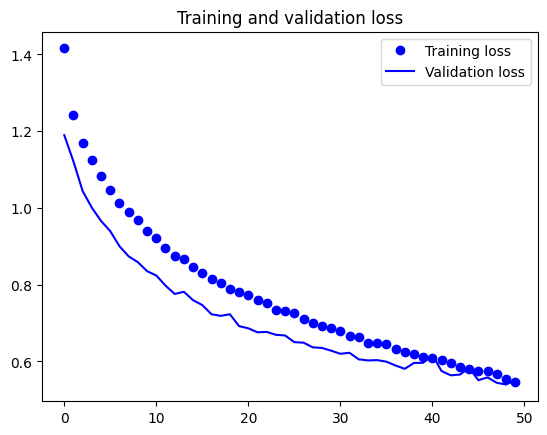

In [42]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [43]:
predicted_classes2 = sport_model.predict(test_X)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [44]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [45]:
predicted_classes.shape, test_Y.shape

((5009,), (5009,))

# Aprendamos de los errores: Qué mejorar

Found 3984 correct labels


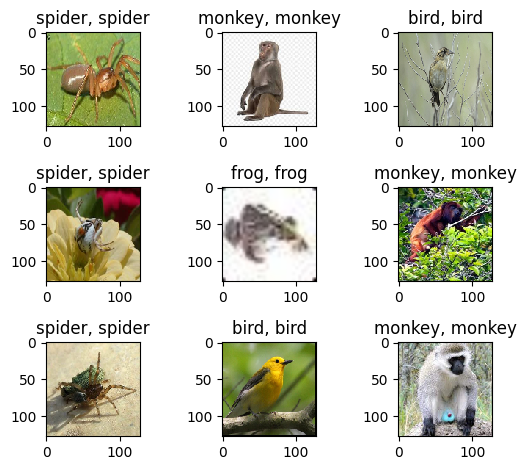

In [46]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(128,128,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 1025 incorrect labels


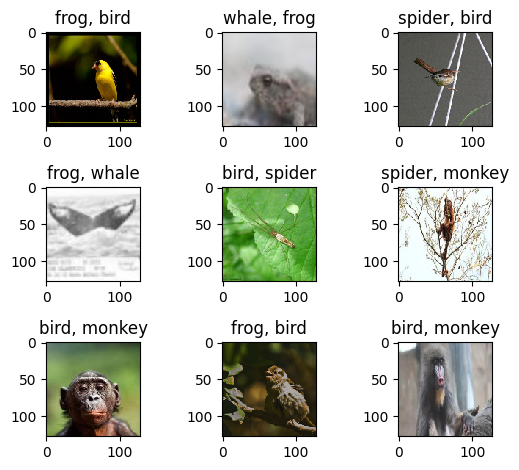

In [47]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(128,128,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [125]:
from skimage.transform import resize

images=[]
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = ['C:/Users/adria/Downloads/ballena5.jpg']
#filenames = ['/content/12.jpg']
for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (128, 128),anti_aliasing=True,clip=False,preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
C:/Users/adria/Downloads/ballena5.jpg bird


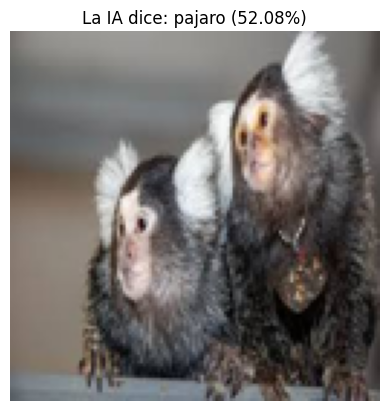

Desglose matemático: [[0.520791   0.06161901 0.22036879 0.18032166 0.01689954]]


In [52]:
from tensorflow.keras.models import load_model  # ← esta línea faltaba
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
transfer_model = load_model('C:/Users/adria/Desktop/Carpetas/Escuela/IA/Proyecto 2/50epocas128CNN.keras')

def predecir_imagen_google(ruta_imagen):
    # El diccionario EXACTO de tu libreta
    clases_animales = ['pajaro', 'rana', 'mono', 'arana', 'ballena'] 

    try:
        # 1. ESCUDO ANTI-FORMATOS: Forzamos la imagen a RGB puro. 
        # Esto elimina fondos negros de los PNG y arregla los WEBP de Google.
        img_pil = Image.open(ruta_imagen).convert('RGB')
        
        # 2. Redimensionamos a 128x128
        img_pil = img_pil.resize((128, 128))
        
        # 3. Convertimos a matriz matemática
        foto_array = np.array(img_pil)
        
        # ==========================================================
        # ⚠️ EL INTERRUPTOR DE LA DIVISIÓN ⚠️
        # Si esta función te falla y lanza cosas locas, descomenta 
        # la línea de abajo (quítale el #) para dividir entre 255. 
        # Depende de cómo ejecutaste tu Celda 3 original.
        # ==========================================================
        foto_array = foto_array / 255.0  
        
        # Empacamos para Keras
        foto_array = np.expand_dims(foto_array, axis=0)

        # 4. Hacemos la predicción
        # (Asegúrate de que 'transfer_model' sea el nombre activo de tu modelo)
        prediccion_numeros = transfer_model.predict(foto_array, verbose=0)
        indice_ganador = np.argmax(prediccion_numeros)
        porcentaje_seguridad = np.max(prediccion_numeros) * 100

        # 5. Mostramos la imagen limpia y el resultado
        plt.imshow(img_pil)
        plt.axis('off')
        plt.title(f"La IA dice: {clases_animales[indice_ganador]} ({porcentaje_seguridad:.2f}%)")
        plt.show()
        
        print(f"Desglose matemático: {prediccion_numeros}")

    except Exception as e:
        print(f"Error procesando la imagen del profe: {e}")


predecir_imagen_google('C:/Users/adria/Downloads/monos10.jpg')